In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# EnhancedNormModel 224x224 Image and 5 Conv Blocks
# Using OverSampled high-alert and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.EnhancedNormModel import EnhancedNormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 2
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 16` 
* `initial_image_size = 128`
* `poolings = [1,1,1,1]`
* `normalizations = [1, 1, 1, 1]`,
* `dropouts = [0, 1, 0, 1]`

In [6]:
model = EnhancedNormModel(
    conv_layers=5, 
    normalizations = [1, 1, 1, 1, 1],
    poolings = [1,1,1,1, 1],
    dropouts = [0, 0, 1, 0, 1],
    initial_output_channel=16, 
    initial_image_size=224,
    dropout_p = 0.2
    ).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=100,
    lr=0.002,
    print_on=5,
    save_dir="../models/en_norm_img224_c5_lr_0.002_os/",
    save_checkpoints=1,
    checkpoint_name="en_norm_224x224_train_0_",
    early_stop_patience = 15,
    min_delta = 0.001
)

Epoch 5/100 | Train Loss: 0.5125 | Valid Loss: 1.0408
Epoch 10/100 | Train Loss: 0.3535 | Valid Loss: 0.7488
Epoch 15/100 | Train Loss: 0.2853 | Valid Loss: 0.6605
Epoch 20/100 | Train Loss: 0.2343 | Valid Loss: 0.7858
Epoch 25/100 | Train Loss: 0.2112 | Valid Loss: 1.1997
Early stopping at epoch 30 | No improvement for 15 epochs


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [9]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,1.353395,0.558789,0.559229,0.559124,0.559146,1.097629,0.567556,0.562312,0.523610,0.447222
1,2,0.791901,0.685792,0.684064,0.685147,0.684537,2.100937,0.492164,0.583618,0.500025,0.334679
2,3,0.656610,0.737978,0.737283,0.738326,0.737737,0.857312,0.676832,0.594707,0.628209,0.580052
3,4,0.583674,0.767350,0.766137,0.767289,0.766632,0.850370,0.700127,0.666039,0.635133,0.619966
4,5,0.512541,0.793989,0.793403,0.794435,0.793831,1.040761,0.620500,0.581397,0.592995,0.520904
5,6,0.461430,0.816211,0.814723,0.815538,0.815069,1.112078,0.598899,0.596200,0.586833,0.493711
6,7,0.428391,0.832878,0.831845,0.832782,0.832239,1.114451,0.668361,0.596961,0.607439,0.577093
7,8,0.396842,0.840346,0.839417,0.840287,0.839795,0.710457,0.749682,0.634371,0.669659,0.646911
8,9,0.380029,0.853871,0.852831,0.853701,0.853190,0.758198,0.714528,0.606492,0.646478,0.605971
9,10,0.353470,0.860337,0.859638,0.860462,0.859998,0.748841,0.738247,0.619549,0.665183,0.627543


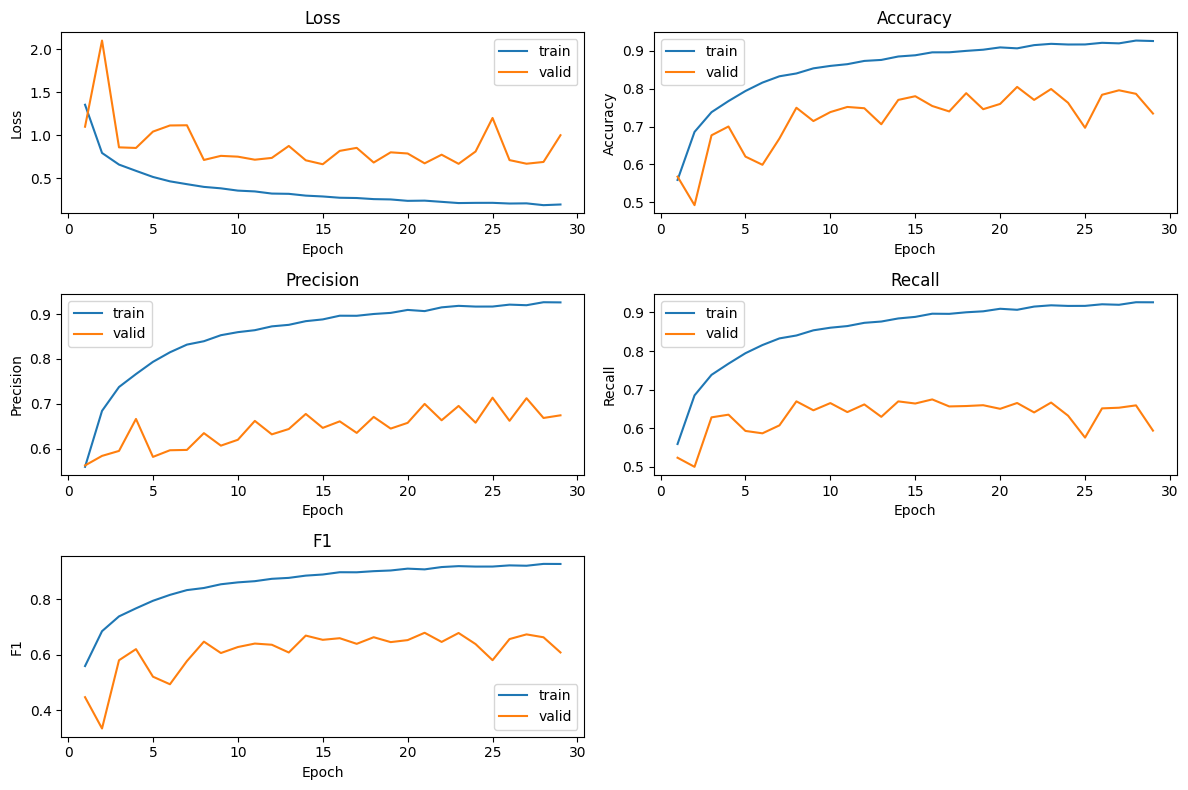

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()